In [1]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.pyplot as plt
import transformers
from transformers import AutoTokenizer
from transformers import  BertForTokenClassification

from torch.optim import AdamW

import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score

In [3]:
class DistilbertNER(nn.Module):
  """
  Implement NN class based on distilbert pretrained from Hugging face.
  Inputs : 
    tokens_dim : int specifyng the dimension of the classifier
  """
  
  def __init__(self, tokens_dim):
    super(DistilbertNER,self).__init__()
    
    if type(tokens_dim) != int:
            raise TypeError('Please tokens_dim should be an integer')

    if tokens_dim <= 0:
          raise ValueError('Classification layer dimension should be at least 1')

    self.pretrained = BertForTokenClassification.from_pretrained("bert-base-cased", num_labels = tokens_dim) 

  def forward(self, input_ids, attention_mask, labels = None):
    """
  Forwad computation of the network
  Input:
    - inputs_ids : from model tokenizer
    - attention :  mask from model tokenizer
    - labels : if given the model is able to return the loss value
  """

    #inference time no labels
    if labels == None:
      out = self.pretrained(input_ids = input_ids, attention_mask = attention_mask )
      return out

    out = self.pretrained(input_ids = input_ids, attention_mask = attention_mask , labels = labels)
    return out

In [4]:
class NerDataset(torch.utils.data.Dataset):
    """
    Custom dataset implementation to get (text, labels) tuples
    """
    def __init__(self, df):
        if not isinstance(df, pd.DataFrame):
            raise TypeError('Input should be a dataframe')
            
        texts = df["Ingredient_Phrases"].values.tolist()
        tags_list = [i.split() for i in df["Labels"].values.tolist()]

        self.texts = [tokenizer(text, padding="max_length", truncation=True, return_tensors="pt") for text in texts]
        self.labels = [match_tokens_labels(text, tags) for text, tags in zip(self.texts, tags_list)]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        batch_text = self.texts[idx]
        batch_labels = self.labels[idx]

        return batch_text, torch.LongTensor(batch_labels)

In [5]:
class MetricsTracking():
  """
  In order make the train loop lighter I define this class to track all the metrics that we are going to measure for our model.
  """
  def __init__(self):

    self.total_acc = 0
    self.total_f1 = 0
    self.total_precision = 0
    self.total_recall = 0

  def update(self, predictions, labels , ignore_token = -100):
    '''
    Call this function every time you need to update your metrics.
    Where in the train there was a -100, were additional token that we dont want to label, so remove them.
    If we flatten the batch its easier to access the indexed = -100
    '''  
    predictions = predictions.flatten()
    labels = labels.flatten()
    
    predictions = predictions[labels != ignore_token]
    labels = labels[labels != ignore_token]

    predictions = predictions.to("cpu")
    labels = labels.to("cpu")

    acc = accuracy_score(labels,predictions)
    f1 = f1_score(labels, predictions, average = "macro")
    precision = precision_score(labels, predictions, average = "macro")
    recall = recall_score(labels, predictions, average = "macro")

    self.total_acc  += acc
    self.total_f1 += f1
    self.total_precision += precision
    self.total_recall  += recall

  def return_avg_metrics(self,data_loader_size):
    n = data_loader_size
    metrics = {
        "acc": round(self.total_acc / n ,3), 
        "f1": round(self.total_f1 / n, 3), 
        "precision" : round(self.total_precision / n, 3), 
        "recall": round(self.total_recall / n, 3)
          }
    return metrics   

In [6]:
def match_tokens_labels(tokenized_input, tags, ignore_token=-100):
    word_ids = tokenized_input.word_ids()
    previous_word_idx = None
    label_ids = []

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(ignore_token)
        else:
            try:
                reference_tag = tags[word_idx]
                label_ids.append(tag2idx[reference_tag])
            except:
                label_ids.append(ignore_token)

        previous_word_idx = word_idx

    return label_ids
    
def tags_mapping(tags_series):
    unique_tags = set()

    for tag_list in tags_series:
        for tag in tag_list.split():
            unique_tags.add(tag)

    tag2idx = {k: v for v, k in enumerate(sorted(unique_tags))}
    idx2tag = {v: k for v, k in tag2idx.items()}

    unseen_label = tag2idx["O"]

    return tag2idx, idx2tag, unseen_label, unique_tags

In [7]:
def freeze_model(model,num_layers = 1):
  """
  Freeze last num_layers of a model to prevent ctastrophic forgetting.
  Doesn't seem to work weel, its better to fine tune the entire netwok
  """
  for id , params in enumerate(model.parameters()):
    if id == len(list(model.parameters())) - num_layers: 
      print("last layer unfreezed")
      params.requires_grad = True
    else:
      params.requires_grad = False
  return model

In [8]:
def train_loop(model, train_dataset, dev_dataset, optimizer,  batch_size, epochs):

  train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
  dev_dataloader = DataLoader(dev_dataset, batch_size = batch_size, shuffle = True)

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)

  train_metrics_list = {'loss':[], 'acc':[], 'precision':[], 'recall':[], 'f1':[] }
  test_metrics_list = {'loss':[], 'acc':[], 'precision':[], 'recall':[], 'f1':[] }



  for epoch in range(epochs): 
    
    train_metrics = MetricsTracking()
    total_loss_train = 0

    model.train() #train mode

    for train_data, train_label in tqdm(train_dataloader):

      train_label = train_label.to(device)
      '''
      squeeze in order to match the sizes. From [batch,1,seq_len] --> [batch,seq_len] 
      '''
      mask = train_data['attention_mask'].squeeze(1).to(device)
      input_id = train_data['input_ids'].squeeze(1).to(device)

      optimizer.zero_grad()
      
      output = model(input_id, mask, train_label)
      loss, logits = output.loss, output.logits
      predictions = logits.argmax(dim= -1) 

      #computing metrics
      train_metrics.update(predictions, train_label)
      total_loss_train += loss.item()

      #grad step
      loss.backward()
      optimizer.step()
    
    '''
    EVALUATION MODE
    '''            
    model.eval()

    dev_metrics = MetricsTracking()
    total_loss_dev = 0
    
    with torch.no_grad():
      for dev_data, dev_label in dev_dataloader:

        dev_label = dev_label.to(device)

        mask = dev_data['attention_mask'].squeeze(1).to(device)
        input_id = dev_data['input_ids'].squeeze(1).to(device)

        output = model(input_id, mask, dev_label)
        loss, logits = output.loss, output.logits

        predictions = logits.argmax(dim= -1)     

        dev_metrics.update(predictions, dev_label)
        total_loss_dev += loss.item()
    
    train_results = train_metrics.return_avg_metrics(len(train_dataloader))
    dev_results = dev_metrics.return_avg_metrics(len(dev_dataloader))

    train_metrics_list['loss'].append(total_loss_train / len(train_dataset))
    train_metrics_list['acc'].append(train_results['acc'])
    train_metrics_list['precision'].append(train_results['precision'])
    train_metrics_list['recall'].append(train_results['recall'])
    train_metrics_list['f1'].append(train_results['f1'])

    test_metrics_list['loss'].append(total_loss_dev / len(dev_dataset))
    test_metrics_list['acc'].append(dev_results['acc'])
    test_metrics_list['precision'].append(dev_results['precision'])
    test_metrics_list['recall'].append(dev_results['recall'])
    test_metrics_list['f1'].append(dev_results['f1'])

    print(f"TRAIN \nLoss: {total_loss_train / len(train_dataset)} \nMetrics {train_results}\n" ) 
    print(f"VALIDATION \nLoss {total_loss_dev / len(dev_dataset)} \nMetrics{dev_results}\n" )
  return train_metrics_list, test_metrics_list

In [8]:
from sklearn.model_selection import train_test_split
df_new = pd.read_csv('./NEW_Annotated_Dataset_NER.csv')


df_train, df_test = train_test_split(df_new, test_size=0.2, random_state=42)

df_dev = df_test  

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [9]:
import re

# Function to clean the labels
def clean_labels(label_column):
    cleaned_labels = []
    for label_list in label_column:
        cleaned_label = re.sub(r"[\[\]']", "", label_list)
        cleaned_label = cleaned_label.replace(",", "") 
        cleaned_labels.append(cleaned_label.strip()) 
    return cleaned_labels

df_train["Labels"] = clean_labels(df_train["Labels"])
df_test["Labels"] = clean_labels(df_test["Labels"])

# Checking the unique cleaned labels
print(df_train["Labels"].unique())

['QUANTITY NAME O STATE STATE O'
 'QUANTITY UNIT DF NAME FORM O STATE STATE'
 'O O O O O O O O O O O O O O O O' ... 'QUANTITY UNIT O O NAME O O O'
 'QUANTITY UNIT O NAME NAME O O O O O O O O O O NAME O O O O O'
 'QUANTITY NAME NAME O QUANTITY O O O']


In [10]:
#tag-label mapping
tag2idx, idx2tag , unseen_label, unique_tags = tags_mapping(df_train["Labels"])

def tags_2_labels(tags: str, tag2idx: dict):
    return [tag2idx[tag] if tag in tag2idx else unseen_label for tag in tags.split()]
for df in [df_train, df_dev, df_test]:
    df["labels"] = df["Labels"].apply(lambda tags: tags_2_labels(tags, tag2idx))

In [11]:
# Ensuring all entries in 'Ingredient_Phrases' are strings
df_train["Ingredient_Phrases"] = df_train["Ingredient_Phrases"].astype(str)

df_train = df_train[df_train["Ingredient_Phrases"].str.strip() != '']  
df_train = df_train.dropna(subset=["Ingredient_Phrases"])  

text_tokenized = tokenizer(df_train["Ingredient_Phrases"].values.tolist(),padding='max_length', truncation=True, return_tensors="pt")

In [13]:
model = DistilbertNER(len(unique_tags))

#datasets
train_dataset = NerDataset(df_train)
dev_dataset = NerDataset(df_dev)

lr = 1e-2
optimizer = SGD(model.parameters(), lr=lr, momentum = 0.9)  

#MAIN
parameters = {
    "model": model,
    "train_dataset": train_dataset,
    "dev_dataset" : dev_dataset,
    "optimizer" : optimizer,
    "batch_size" : 32,
    "epochs" : 8
}

train_metrics_list, test_metrics_list = train_loop(**parameters)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


TRAIN 
Loss: 0.01661910838986698 
Metrics {'acc': 0.825, 'f1': 0.693, 'precision': 0.723, 'recall': 0.691}

VALIDATION 
Loss 0.011074555351545936 
Metrics{'acc': 0.888, 'f1': 0.816, 'precision': 0.852, 'recall': 0.815}



100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


TRAIN 
Loss: 0.0096729262624132 
Metrics {'acc': 0.899, 'f1': 0.816, 'precision': 0.841, 'recall': 0.818}

VALIDATION 
Loss 0.009270962892394317 
Metrics{'acc': 0.908, 'f1': 0.859, 'precision': 0.891, 'recall': 0.851}



100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


...

TRAIN 
Loss: 0.005006882524313895 
Metrics {'acc': 0.945, 'f1': 0.896, 'precision': 0.907, 'recall': 0.904}

VALIDATION 
Loss 0.009214036550961043 
Metrics{'acc': 0.917, 'f1': 0.883, 'precision': 0.889, 'recall': 0.896}



100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


TRAIN 
Loss: 0.004145591182046031 
Metrics {'acc': 0.954, 'f1': 0.916, 'precision': 0.922, 'recall': 0.925}

VALIDATION 
Loss 0.009711420155669514 
Metrics{'acc': 0.919, 'f1': 0.895, 'precision': 0.895, 'recall': 0.915}



100%|██████████| 238/238 [02:27<00:00,  1.62it/s]


TRAIN 
Loss: 0.003755672632373477 
Metrics {'acc': 0.957, 'f1': 0.926, 'precision': 0.933, 'recall': 0.934}

VALIDATION 
Loss 0.009895009759225344 
Metrics{'acc': 0.917, 'f1': 0.886, 'precision': 0.895, 'recall': 0.896}



In [14]:
train_metrics_list 

{'loss': [0.01661910838986698,
  0.0096729262624132,
  0.007863239978293055,
  0.006594498305532493,
  0.00564821551504888,
  0.005006882524313895,
  0.004145591182046031,
  0.003755672632373477],
 'acc': [0.825, 0.899, 0.917, 0.928, 0.938, 0.945, 0.954, 0.957],
 'precision': [0.723, 0.841, 0.873, 0.895, 0.903, 0.907, 0.922, 0.933],
 'recall': [0.691, 0.818, 0.861, 0.888, 0.904, 0.904, 0.925, 0.934],
 'f1': [0.693, 0.816, 0.855, 0.882, 0.894, 0.896, 0.916, 0.926]}

# BERT MODEL

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split


file_path = '/home/ritisha21089/btp/data/'
df = pd.read_csv(file_path + '6500_dataset.csv')

# Define test size (e.g., 80% train, 20% test)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

In [19]:
train_df.head()

,Ingredient_Phrases,Labels
2851,"1 large onion , cut into slivers","['QUANTITY', 'SIZE', 'NAME', 'O', 'PREPROCESSI..."
4918,4 cups water or 4 cups mild vegetable stock,"['QUANTITY', 'UNIT', 'NAME', 'O', 'QUANTITY', ..."
5690,8 ounces cooked chicken breasts,"['QUANTITY', 'UNIT', 'STATE', 'NAME', 'NAME']"
4262,"2 lbs sirloin steaks , sliced into 1/4 inch pi...","['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'PRE..."
4975,"melted chocolate , to decorate","['STATE', 'NAME', 'O', 'O', 'O']"


In [4]:
import pandas as pd

unique_tags = set()


for tags in train_df['Labels']:

    tag_list = tags.split()
    unique_tags.update(tag_list)


unique_tags = list(unique_tags)

print(unique_tags)

["['NAME',", "'O',", "'FORM',", "'O']", "'SIZE']", "['UNIT',", "'PREPROCESSING',", "'STATE',", "'DF']", "'DF',", "'FORM']", "'QUANTITY',", "'QUANTITY']", "'STATE']", "['O']", "'NAME']", "['SIZE',", "'NAME',", "'UNIT',", "'SIZE',", "['FORM',", "['O',", "['QUANTITY',", "['STATE',", "'PREPROCESSING']", "['NAME']", "'UNIT']"]


In [20]:
test_df.head()

,Ingredient_Phrases,Labels
5572,"1/2 teaspoon cumin seed , toasted","['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'PRE..."
1703,"3 boneless skinless chicken breasts , cubed -L...","['QUANTITY', 'STATE', 'STATE', 'NAME', 'NAME',..."
5862,1 1/2 cups canned tomatoes -LRB- drain and res...,"['QUANTITY', 'QUANTITY', 'UNIT', 'STATE', 'NAM..."
1773,"1/2 cup boneless chicken breast , cooked","['QUANTITY', 'UNIT', 'STATE', 'NAME', 'NAME', ..."
5709,16 ounces refrigerated pizza dough -LRB- see R...,"['QUANTITY', 'UNIT', 'STATE', 'NAME', 'NAME', ..."


In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, BertForTokenClassification, AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


# BERT-based NER class
class BertNER(nn.Module):
    def __init__(self, tokens_dim):
        super(BertNER, self).__init__()
        
        if type(tokens_dim) != int:
            raise TypeError('tokens_dim should be an integer')
        if tokens_dim <= 0:
            raise ValueError('Classification layer dimension should be at least 1')

        self.pretrained = BertForTokenClassification.from_pretrained("bert-base-cased", num_labels=tokens_dim)

    def forward(self, input_ids, attention_mask, labels=None):
        """
        Forward pass of the network.
        """
        if labels is None:
            return self.pretrained(input_ids=input_ids, attention_mask=attention_mask)
        return self.pretrained(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    
    def save_pretrained(self, save_directory):
        """
        Save the pretrained model to the specified directory.
        """
        self.pretrained.save_pretrained(save_directory)

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [7]:
class NerDataset(Dataset):
    """
    Custom dataset class for NER tasks.
    """

    def __init__(self, dataframe, tokenizer, label_map, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # Convert the 'sentence' column to string
        text = str(row['sentence'])

        # Split the 'tags' column by space to get individual labels
        labels = row['tags'].split()

        # Tokenize the sentence
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
            return_attention_mask=True,
            is_split_into_words=False
        )

        # Initialize label IDs as -100 (ignore index) by default for max length
        label_ids = [-100] * self.max_len
        word_ids = encoding.word_ids()

        # Assign labels to the appropriate tokens
        for i, word_id in enumerate(word_ids):
            if word_id is None or word_id >= len(labels):
                # Ignore non-word tokens or tokens beyond the sentence length
                label_ids[i] = -100
            else:
                # Map the tag to its corresponding label ID from the label_map
                label_ids[i] = self.label_map.get(labels[word_id], -100)

        # Convert everything to PyTorch tensors
        input_ids = encoding['input_ids'].flatten()
        attention_mask = encoding['attention_mask'].flatten()
        label_ids = torch.tensor(label_ids)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_ids
        }

# Example label map (you can modify it based on your requirements)
label_map = {
    'DF': 0,
    'QUANTITY': 1,
    'SIZE': 2,
    'O': -100,  # Outside token or padding
    'STATE': 3,
    'NAME': 4,
    'FORM': 5,
    'UNIT': 6,
    'PREPROCESSING':7
}
# ['SIZE', 'QUANTITY', 'DF', 'TEMP', 'STATE', 'O', 'UNIT', 'NAME']

# label_mapping = {
#         'Quantity': 'QUANTITY',
#         'Unit': 'UNIT',
#         'Ingredient Name': 'NAME',
#         'Form': 'FORM',
#         'State': 'STATE',
#         'Dry/Fresh': 'DF',
#         'Size': 'SIZE',
#         'Preprocessing': 'PREPROCESSING'
#     }


In [22]:
class NerDataset(Dataset):
    """
    Custom dataset class for NER tasks.
    """

    def __init__(self, dataframe, tokenizer, label_map, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # to ensure the 'Ingredient_Phrases' column is a string
        text = str(row['sentence'])

        labels = row['tags']

        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
            return_attention_mask=True,
            is_split_into_words=False
        )

        # Converting labels to match tokenization
        label_ids = [-100] * self.max_len 
        word_ids = encoding.word_ids()

        labels_list = eval(labels)  

        # Assigning NER labels for each word
        for i, word_id in enumerate(word_ids):
            if word_id is None or word_id >= len(labels_list):
                label_ids[i] = -100
            else:
                label_ids[i] = self.label_map.get(labels_list[word_id], -100)

        input_ids = encoding['input_ids'].flatten()
        attention_mask = encoding['attention_mask'].flatten()
        label_ids = torch.tensor(label_ids)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_ids
        }

label_map = {
    'DF': 0,
    'QUANTITY': 1,
    'SIZE': 2,
    'O': -100,  # Outside token or padding
    'STATE': 3,
    'NAME': 4,
    'FORM': 5,
    'UNIT': 6,
    'PREPROCESSING':7
}

# label_map = { 'DF': 0, 'QUANTITY': 1, 'SIZE': 2, 'O': -100, 'STATE': 3, 'NAME': 4, 'TEMP': 5, 'UNIT': 6}

#{'DF': 0, 'FORM': 1, 'NAME': 2, 'O': 3, 'PREPROCESSING': 4, 'QUANTITY': 5, 'SIZE': 6, 'STATE': 7, 'UNIT': 8}


In [23]:
from torch.utils.data import DataLoader

train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
test_dataset = NerDataset(dataframe=test_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size)


In [24]:
tokens_dim = len(label_map) 
model = BertNER(tokens_dim=tokens_dim)
optimizer = AdamW(model.parameters(), lr=2e-5) 
epochs = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# model.train()

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/ritisha21089/miniconda3/lib/python3.9/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


BertNER(
  (pretrained): BertForTokenClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(28996, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768, 

In [15]:
for batch in train_loader:
    print(batch.keys())  # Debugging step
    break

KeyError: 'sentence'

In [25]:
for epoch in range(epochs):
    total_loss = 0
    model.train()
    for batch in train_loader:  
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:  # test_loader is your DataLoader for the testing data
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

KeyError: 'sentence'

In [25]:
# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

# Precision: 0.9896
# Recall: 0.9939
# F1-Score: 0.9917

Precision: 0.9554
Recall: 0.9541
F1-Score: 0.9547


In [23]:
from transformers import BertForTokenClassification, BertTokenizer
import torch

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved model and tokenizer
saved_model_dir = "./saved_bert_model/"

# Load the saved model
print("Loading the model...")
model = BertNER(tokens_dim=len(label_map))  # Ensure you pass the correct number of labels
model.pretrained = BertForTokenClassification.from_pretrained(saved_model_dir)

# Load the saved tokenizer
tokenizer = AutoTokenizer.from_pretrained(saved_model_dir)

# Move model to the appropriate device
model.to(device)

print(f"Model and tokenizer loaded from {output_dir}")

Loading the model...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model and tokenizer loaded from ./saved_bert_model/


In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# # Perform a train-test split (80% train, 20% test)
# train_idx, val_idx = train_test_split(range(len(ner_dataset)), test_size=0.2, random_state=42)

# # Subset the dataset for train and validation based on indices
# train_dataset = Subset(ner_dataset, train_idx)
# val_dataset = Subset(ner_dataset, val_idx)

# # Create DataLoader for train and validation
# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training and evaluation loop similar to K-Fold approach
train_loss_history = []
val_loss_history = []

model.train()
for epoch in range(epochs):
    total_loss = 0
    total_val_loss = 0

    # Training loop
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Calculate average training loss
    avg_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_loss:.4f}")

    # Validation loop
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss = outputs.loss
            total_val_loss += val_loss.item()

    # Calculate average validation loss
    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {avg_val_loss:.4f}")

# Evaluation on the test set
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:  # Ignoring padding or special tokens
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

# Flatten predictions and true labels
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

# Calculate metrics for the train-test split
precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f"Train-Test Split - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
print("Classification Report for Train-Test Split:\n")
print(classification_report(flat_true_labels, flat_predictions))

# Plot train-test split loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, linestyle='--', label='Validation Loss')
plt.title('Training and Validation Loss Curves for Train-Test Split')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


KeyError: 'sentence'

Train-Test Split - Precision: 0.9689, Recall: 0.9403, F1-Score: 0.9539
Classification Report for Train-Test Split:

              precision    recall  f1-score   support

           0       0.92      0.87      0.90        95
           1       1.00      1.00      1.00      1012
           2       0.98      0.94      0.96        48
           3       0.96      0.96      0.96       804
           4       0.98      0.99      0.99      2585
           5       0.95      0.84      0.89        25
           6       0.98      0.99      0.98      1215

    accuracy                           0.98      5784
   macro avg       0.97      0.94      0.95      5784
weighted avg       0.98      0.98      0.98      5784



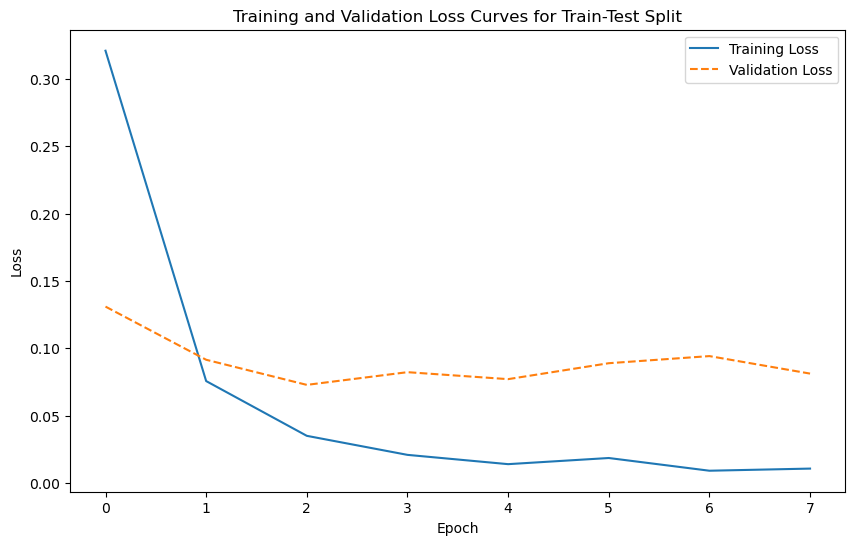

In [13]:
import matplotlib.pyplot as plt

print(f"Train-Test Split - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
print("Classification Report for Train-Test Split:\n")
print(classification_report(flat_true_labels, flat_predictions))

# Plot train-test split loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, linestyle='--', label='Validation Loss')
plt.title('Training and Validation Loss Curves for Train-Test Split')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Cross validation

Fold 1/5
Epoch 1/8, Training Loss: 0.0184
Epoch 1/8, Validation Loss: 0.0172
Epoch 2/8, Training Loss: 0.0084
Epoch 2/8, Validation Loss: 0.0186
Epoch 3/8, Training Loss: 0.0069
Epoch 3/8, Validation Loss: 0.0188
Epoch 4/8, Training Loss: 0.0073
Epoch 4/8, Validation Loss: 0.0210
Epoch 5/8, Training Loss: 0.0044
Epoch 5/8, Validation Loss: 0.0184
Epoch 6/8, Training Loss: 0.0091
Epoch 6/8, Validation Loss: 0.0258
Epoch 7/8, Training Loss: 0.0069
Epoch 7/8, Validation Loss: 0.0367
Epoch 8/8, Training Loss: 0.0072
Epoch 8/8, Validation Loss: 0.0296
Fold 1 - Precision: 0.9821, Recall: 0.9780, F1-Score: 0.9799
Classification Report for Fold 1:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2077
           1       0.99      1.00      0.99      2174
           2       0.99      0.99      0.99      5468
           3       0.98      0.92      0.95       211
           4       0.99      0.98      0.99      3181
           5       0.96   

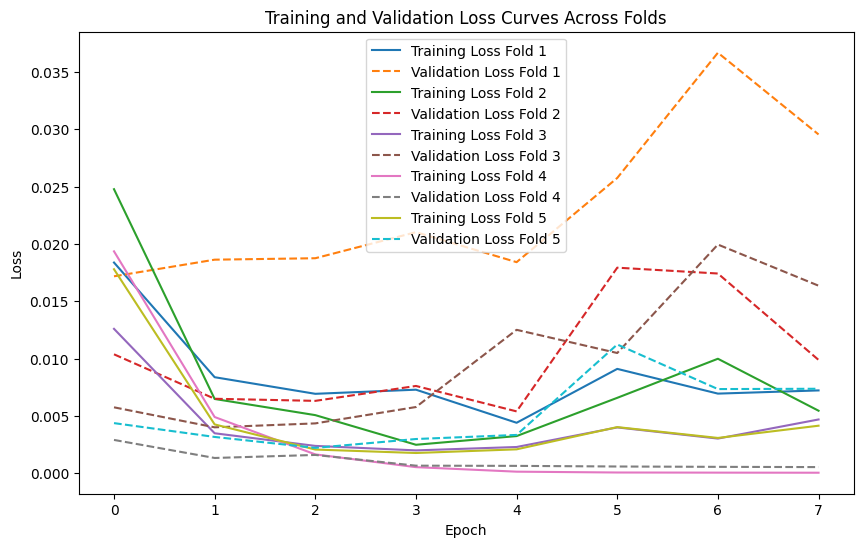

In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

k_folds = 5

# Initialize KFold
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Lists to store metrics for each fold
all_precisions = []
all_recalls = []
all_f1_scores = []
fold_loss_history = []  # Store loss for each epoch in each fold
val_loss_history = []  # Store validation loss for each epoch in each fold

for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    print(f"Fold {fold + 1}/{k_folds}")
    
    # Subset the dataset for train and validation based on indices
    train_dataset = Subset(ner_dataset, train_idx)
    val_dataset = Subset(ner_dataset, val_idx)
    
    # Create DataLoader for train and validation
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # Train the model
    model.train()
    epoch_loss = []  # Track the loss for each epoch
    epoch_val_loss = []  # Track validation loss for each epoch

    for epoch in range(epochs):
        total_loss = 0
        total_val_loss = 0  # For tracking validation loss

        # Training loop
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Calculate the average training loss
        avg_loss = total_loss / len(train_loader)
        epoch_loss.append(avg_loss)  # Store loss for this epoch
        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_loss:.4f}")

        # Validation loop
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                # Forward pass
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss = outputs.loss

                total_val_loss += val_loss.item()

        # Calculate the average validation loss
        avg_val_loss = total_val_loss / len(val_loader)
        epoch_val_loss.append(avg_val_loss)  # Store validation loss for this epoch
        print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {avg_val_loss:.4f}")

    fold_loss_history.append(epoch_loss)  # Store loss history for this fold
    val_loss_history.append(epoch_val_loss)  # Store validation loss history for this fold

    # Evaluation on the validation set
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            logits = logits.detach().cpu().numpy()
            label_ids = labels.cpu().numpy()

            for i in range(len(label_ids)):
                pred_labels = []
                true_label = []
                for j in range(len(label_ids[i])):
                    if label_ids[i][j] != -100:  # Ignoring padding or special tokens
                        true_label.append(label_ids[i][j])
                        pred_label = np.argmax(logits[i][j])
                        pred_labels.append(pred_label)
                predictions.append(pred_labels)
                true_labels.append(true_label)

    # Flatten predictions and true labels
    flat_predictions = [item for sublist in predictions for item in sublist]
    flat_true_labels = [item for sublist in true_labels for item in sublist]

    # Calculate metrics for this fold
    precision = precision_score(flat_true_labels, flat_predictions, average='macro')
    recall = recall_score(flat_true_labels, flat_predictions, average='macro')
    f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

    # Store metrics for this fold
    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1_scores.append(f1)

    print(f"Fold {fold + 1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    # Print classification report for this fold
    print(f"Classification Report for Fold {fold + 1}:\n")
    print(classification_report(flat_true_labels, flat_predictions))

# After cross-validation, calculate average metrics
avg_precision = np.mean(all_precisions)
avg_recall = np.mean(all_recalls)
avg_f1 = np.mean(all_f1_scores)

print(f"\nCross-Validation Results ({k_folds} Folds):")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-Score: {avg_f1:.4f}")

# Plot loss curves for each fold (training and validation)
plt.figure(figsize=(10, 6))
for fold_idx in range(k_folds):
    plt.plot(fold_loss_history[fold_idx], label=f'Training Loss Fold {fold_idx + 1}')
    plt.plot(val_loss_history[fold_idx], linestyle='--', label=f'Validation Loss Fold {fold_idx + 1}')
plt.title('Training and Validation Loss Curves Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [9]:
print(all_precisions)
print(all_recalls)
print(all_f1_scores)



[0.9821072906253534, 0.9902274121798083, 0.9923915488901608, 0.999933368869936, 0.9984458511872454]
[0.9780374934140542, 0.9912090839439417, 0.9844475643883086, 0.9999734169812324, 0.9958325151319669]
[0.9798973975952262, 0.9906522517108295, 0.9883314429066354, 0.9999533839175191, 0.9971242414584314]


# Bucket Analysis

In [2]:
import pandas as pd

df = pd.read_csv('/home/ritisha21089/NEW_Annotated_Dataset_NER.csv')

unique_labels = set()
for labels in df['Labels']:
    labels_list = eval(labels) 
    unique_labels.update(labels_list)

label_map = {label: idx for idx, label in enumerate(sorted(unique_labels))}

print(label_map)


{'DF': 0, 'FORM': 1, 'NAME': 2, 'O': 3, 'PREPROCESSING': 4, 'QUANTITY': 5, 'SIZE': 6, 'STATE': 7, 'UNIT': 8}


In [7]:
#Visualizing entity lengths to define the bin
print(df['Entity_Length'].describe())


count    9500.000000
mean        7.871579
std         3.854460
min         0.000000
25%         5.000000
50%         7.000000
75%        10.000000
max        42.000000
Name: Entity_Length, dtype: float64


In [8]:
# Visualizing token frequency of each label to define the bin
print(label_freq.describe())


count    3098.000000
mean        0.000323
std         0.001433
min         0.000105
25%         0.000105
50%         0.000105
75%         0.000211
max         0.057368
Name: Labels, dtype: float64


In [9]:
# Visualizing token frequency distribution to define the bin
print(token_freq.describe())


count    9497.000000
mean        0.000105
std         0.000002
min         0.000105
25%         0.000105
50%         0.000105
75%         0.000105
max         0.000316
Name: Ingredient_Phrases, dtype: float64


In [25]:
import numpy as np

# to ensure the 'Ingredient_Phrases' column has string values and handles NaNs or other non-string types
df['Ingredient_Phrases'] = df['Ingredient_Phrases'].fillna('').astype(str)

df['Entity_Length'] = df['Ingredient_Phrases'].apply(lambda x: len(x.split())) 

df['Entity_Length_Bucket'] = pd.cut(df['Entity_Length'], bins=[0, 4, 9, np.inf], labels=['short', 'medium', 'long'])

label_freq = df['Labels'].explode().value_counts(normalize=True) 
df['Label_Consistency'] = df['Labels'].apply(lambda x: label_freq[x])  

df['Label_Consistency_Bucket'] = pd.cut(df['Label_Consistency'], bins=[0, 0.0005, 0.005, 0.06], labels=['rare', 'common', 'very_common'])

token_freq = df['Ingredient_Phrases'].explode().value_counts(normalize=True)
df['Token_Frequency'] = df['Ingredient_Phrases'].apply(lambda x: token_freq[x])

df['Token_Frequency_Bucket'] = pd.cut(df['Token_Frequency'], bins=[0, 0.0001, 0.0002, 0.00035], labels=['low', 'medium', 'high'])




In [26]:
df

,Ingredient_Phrases,Quantity,Unit,Ingredient Name,Form,State,Dry/Fresh,Size,Preprocessing,Labels,Entity_Length,Entity_Length_Bucket,Label_Consistency,Label_Consistency_Bucket,Token_Frequency,Token_Frequency_Bucket
0,"['5', 'ounces', 'spinach', 'leaves']",5,ounces,spinach,leaves,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'FORM']",4,short,0.006211,very_common,0.000105,medium
1,"['1', 'teaspoon', 'wheat', 'germ', ',', 'if', ...",1,teaspoon,wheat germ,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O',...",10,long,0.004105,common,0.000105,medium
2,"['1/8', 'cup', 'pine', 'nuts', '-LRB-', 'optio...",1/8,cup,pine nuts,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O',...",7,medium,0.009263,very_common,0.000105,medium
3,"['1/4', 'cup', 'sunflower', 'oil']",1/4,cup,sunflower oil,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME']",4,short,0.057368,very_common,0.000105,medium
4,"['1', 'batch', 'jerk', 'sauce', '-LRB-', 'see'...",1,batch,jerk sauce,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O',...",9,medium,0.007684,very_common,0.000105,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9495,"['1', 'lemongrass', '-LRB-', 'sereh', '-RRB-']",1,NaN,lemongrass,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'NAME', 'O', 'O', 'O']",5,medium,0.001474,common,0.000105,medium
9496,"['4', 'ounces', 'anchovies', 'packed', 'in', '...",4,ounces,anchovies packed in oil,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'NAME', '...",6,medium,0.006947,very_common,0.000105,medium
9497,"['1', 'baguette', '-LRB-', 'or', 'other', 'cru...",1,NaN,baguette,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'NAME', 'O', 'O', 'O', 'O', 'O', ...",10,long,0.000316,rare,0.000105,medium
9498,"['12', 'toothpicks', '-LRB-', 'soak', 'them', ...",12,NaN,toothpicks,NaN,soak them in water,NaN,NaN,NaN,"['QUANTITY', 'NAME', 'O', 'STATE', 'STATE', 'S...",8,medium,0.000421,rare,0.000105,medium


In [29]:
from sklearn.metrics import classification_report

# Evaluating per bucket
def evaluate_bucket_performance(df, y_true, y_pred, bucket_column):
    unique_buckets = df[bucket_column].unique()
    for bucket in unique_buckets:
        bucket_indices = df[df[bucket_column] == bucket].index
        y_true_bucket = [y_true[i] for i in bucket_indices]
        y_pred_bucket = [y_pred[i] for i in bucket_indices]
        print(f"Performance for {bucket_column}: {bucket}")
        print(classification_report(y_true_bucket, y_pred_bucket, digits=4))


evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Entity_Length_Bucket')
evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Label_Consistency_Bucket')


Performance for Entity_Length_Bucket: short
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       232
           1     1.0000    1.0000    1.0000       231
           2     1.0000    0.9983    0.9991       575
           3     1.0000    1.0000    1.0000        10
           4     0.9973    1.0000    0.9987       376
           6     1.0000    1.0000    1.0000        14
           7     1.0000    1.0000    1.0000         2

    accuracy                         0.9993      1440
   macro avg     0.9996    0.9998    0.9997      1440
weighted avg     0.9993    0.9993    0.9993      1440

Performance for Entity_Length_Bucket: long
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       387
           1     1.0000    0.9942    0.9971       344
           2     0.9979    0.9979    0.9979       956
           3     0.8824    1.0000    0.9375        15
           4     1.0000    1.0000    1.0000  